# Clustering tips with PhyloWave

## Setup working directory and paths

In [1]:
# Set working directory
setwd("~/Desktop/research-stuff/antigen-forecasting")

# Define function paths and path to the tree
index_comp_script_path <- "scripts/2_1_Index_computation_20240909.R"
lineage_detection_script_path <- "scripts/2_2_Lineage_detection_20240909.R"
newick_tree_path <- "data/flu-simulated-150k-samples-final/phylowave/time_tree.nwk"
metadata_path <- "data/flu-simulated-150k-samples-final/auspice/sequences_metadata.tsv"

## Load in libraries

In [2]:
# Source functions
source(file = index_comp_script_path)
source(file = lineage_detection_script_path)

# Load dependencies
library(ape, quiet = T)
library(phytools, quiet = T)
library(stringr, quiet = T)
library(MetBrewer, quiet = T)
library(parallel, quiet = T)
library(mgcv, quiet = T)
library(cowplot, quiet = T)
library(ggplot2, quiet = T)
#library(ggtree, quiet = T)
library(binom, quiet = T)
library(cmdstanr, quiet = T)

Warning message:
“package ‘ape’ was built under R version 4.4.3”
Warning message:
“package ‘phytools’ was built under R version 4.4.3”
Warning message:
“package ‘maps’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘MetBrewer’ was built under R version 4.4.3”
Warning message:
“package ‘mgcv’ was built under R version 4.4.3”
Warning message:
“package ‘nlme’ was built under R version 4.4.3”
This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.

Warning message:
“package ‘cowplot’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘binom’ was built under R version 4.4.3”
Warning message:
“package ‘cmdstanr’ was built under R version 4.4.3”
This is cmdstanr version 0.9.0

- CmdStanR documentation and vignettes: mc-stan.org/cmdstanr

- CmdStan path: /Users/zthornto/miniforge3/envs/antigen/bin/cmdstan

- CmdStan version: 2.37.0


## Read in newick file and metadata

In [3]:
# Read in newick file and metadata
tree_antigen_sim <- ape::read.tree(newick_tree_path)
tip_metadata_df <- read.csv(metadata_path, sep = "\t")

## Genome information
genome_length <- 1726 # from ref_HA.fasta -- grab link to reference in future
## Mutation rate (in substitutions/site/year)
mutation_rate <- 0.001 # Standard flu H3N2 rate and used in simulation

# Make sure the tree is binary, and ladderized
tree_antigen_sim <- collapse.singles(ladderize(multi2di(tree_antigen_sim, random = F), right = F))


## Grab relevant metadata
names_seqs <- tip_metadata_df$strain
# IMPORTANT: Convert tree branch lengths from substitutions/site to years
# The phylowave index computation expects branch lengths in TIME units, not substitutions
# Formula: time = substitutions_per_site / mutation_rate
cat("Original branch lengths (subs/site):", range(tree_antigen_sim$edge.length), "\n")
cat("Mutation rate:", mutation_rate, "\n")
cat("Converting tree branch lengths from subs/site to years...\n")
tree_antigen_sim$edge.length <- tree_antigen_sim$edge.length / mutation_rate
cat("Branch length range (years):", range(tree_antigen_sim$edge.length), "\n")
cat("Tree should span ~30 years total. If values are >> 30, there's an error!\n")

n_seq <- nrow(tip_metadata_df)
collection_times <- tip_metadata_df$date + 2025 # Convert to decimal year
ag_variants <- tip_metadata_df$clade_membership

Original branch lengths (subs/site): 0 0.016488 
Mutation rate: 0.001 
Converting tree branch lengths from subs/site to years...
Branch length range (years): 0 16.488 
Tree should span ~30 years total. If values are >> 30, there's an error!


## Define Index calculation parameters

In [ ]:
## Parameters for the index calculation
# Timescale: evolutionayry timescale for genetic distance weighting
# For flu over ~30 years, 0.3-0.5 years captures meaningful antigenic variation
timescale <- 0.5 # Moderate smoothing - between noisy (0.3) and flat (2.0)

## Window of time on which to search for samples in the population (in years, not days!)
# Wider window = smoother index, narrower = more local variation
wind <- 0.25 

## Compute genetic distance matrix and indicies

In [5]:
genetic_distance_mat <- dist.nodes.with.names(tree_antigen_sim)

nroot <- length(tree_antigen_sim$tip.label) + 1 ## Root number
distance_to_root <- genetic_distance_mat[nroot, ]
root_height <- collection_times[which(names_seqs == names(distance_to_root[1]))] - distance_to_root[1]
nodes_height <- root_height + distance_to_root[n_seq + (1:(n_seq - 1))]

# Meta-data with all nodes
dataset_with_nodes <- data.frame(
    "ID" = c(1:n_seq, n_seq + (1:(n_seq - 1))),
    "name_seq" = c(names_seqs, n_seq + (1:(n_seq - 1))),
    "time" = c(collection_times, nodes_height),
    "is.node" = c(rep("no", n_seq), rep("yes", (n_seq - 1))),
    "antigen_clade" = c(ag_variants, rep(NA, n_seq - 1))
)

In [6]:
# Compute index of every tip and node
dataset_with_nodes$index <- compute.index(
    time_distance_mat = genetic_distance_mat,
    timed_tree = tree_antigen_sim,
    time_window = wind,
    metadata = dataset_with_nodes,
    mutation_rate = mutation_rate,
    timescale = timescale,
    genome_length = genome_length
)

# Check and clean index values for GAM fitting
cat("Index summary:\n")
print(summary(dataset_with_nodes$index))
cat("N NA:", sum(is.na(dataset_with_nodes$index)), "\n")
cat("N Inf:", sum(is.infinite(dataset_with_nodes$index)), "\n")
cat("N >= 1:", sum(dataset_with_nodes$index >= 1, na.rm = T), "\n")
cat("N <= 0:", sum(dataset_with_nodes$index <= 0, na.rm = T), "\n")

Index summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.00000 0.00000 0.07278 0.25192 0.51379 1.00000       1 
N NA: 1 
N Inf: 0 
N >= 1: 1 
N <= 0: 0 


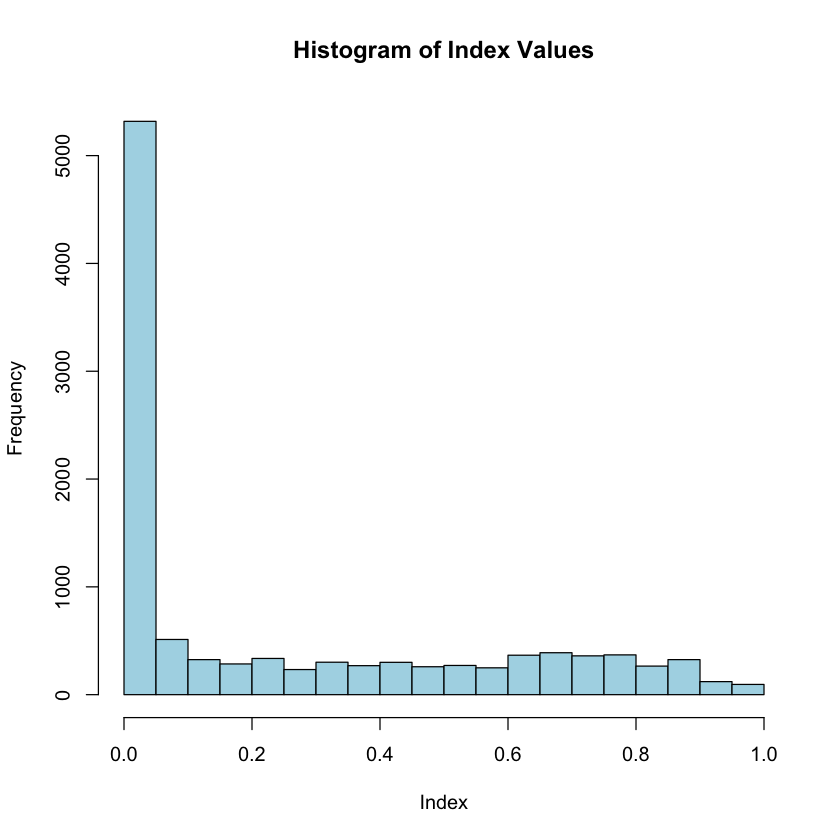

In [7]:
# Plot histogram of index values
hist(dataset_with_nodes$index, breaks = 30, main = "Histogram of Index Values", xlab = "Index", col = "lightblue")

## Plot antigen-cluster indicies

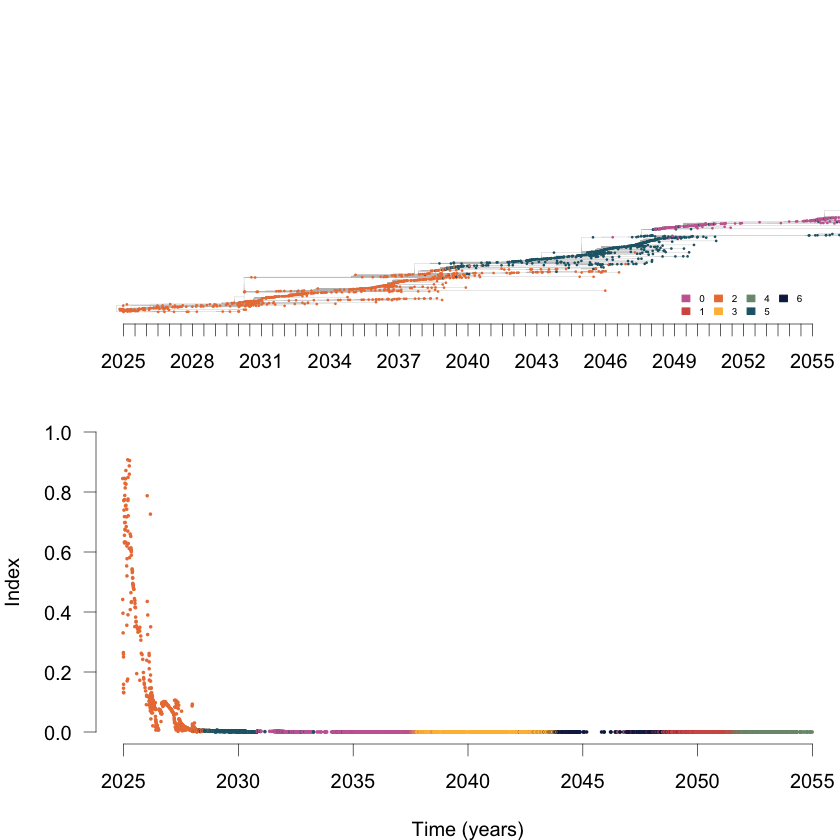

In [8]:
## Color key for antigen clades
colors_clade <- met.brewer(name = "Cross", n = length(levels(as.factor(dataset_with_nodes$antigen_clade))), type = "continuous")

## Color of each node, based on the key
dataset_with_nodes$antigen_clade_color <- as.factor(dataset_with_nodes$antigen_clade)
clade_labels <- levels(dataset_with_nodes$antigen_clade_color)
levels(dataset_with_nodes$antigen_clade_color) <- colors_clade
dataset_with_nodes$antigen_clade_color <- as.character(dataset_with_nodes$antigen_clade_color)

# Plot the antigen clades
par(mfrow = c(2, 1), oma = c(0, 0, 0, 0), mar = c(4, 4, 0, 0))

min_year <- 2025
max_year <- 2055

## Tree
plot(tree_antigen_sim,
    show.tip.label = FALSE,
    edge.color = "grey", edge.width = 0.25,
    x.lim = c(min_year, max_year) - root_height
)
tiplabels(pch = 16, col = dataset_with_nodes$antigen_clade_color, cex = 0.3)
axisPhylo_NL(
    side = 1, root.time = root_height, backward = F,
    at_axis = seq(min_year, max_year, 0.5) - root_height,
    lab_axis = seq(min_year, max_year, 0.5), lwd = 0.5
)
# Color key
legend("bottomright",
    legend = clade_labels,
    fill = colors_clade, border = colors_clade,
    cex = 0.5, bty = "n", ncol = 5
)
## Index
plot(dataset_with_nodes$time,
    dataset_with_nodes$index,
    col = adjustcolor(dataset_with_nodes$antigen_clade_color, alpha.f = 1),
    bty = "n", xlim = c(min_year, max_year), cex = 0.4,
    pch = 16, bty = "n", ylim = c(0, 1),
    main = paste0(""),
    ylab = "Index", xlab = "Time (years)", xaxt = "n", yaxt = "n"
)
axis(2, las = 2, lwd = 0.5)
axis(1, lwd = 0.5)

In [9]:
# Run lineage detection algorithm
# Start at a time window with sufficient data for GAM fitting
# Need at least 2*min_group_size sequences (60+) for reliable split detection
time_window_initial <- 2026.0
# ~113 sequences by this point
time_window_increment <- 2.0
# Increment by 2 years
p_value_smooth <- 0.05
weight_by_time <- NULL
k_smooth <- -1 # Automatic selection - safer for varying data sizes
plot_screening <- F # Enable to see what splits are being found
min_descendants_per_tested_node <- 10
min_group_size <- 10
weighting_transformation <- NULL # Must be NULL when weight_by_time is NULL

parallelize_code <- T # Disable to see actual error messages
number_cores <- 12

max_stepwise_deviance_explained_threshold <- 0
max_groups_found <- 30
stepwise_AIC_threshold <- 0

keep_track <- T


start_time <- Sys.time()
potential_splits <- find.groups.by.index.dynamics(
    timed_tree = tree_antigen_sim,
    metadata = dataset_with_nodes,
    node_support = tree_antigen_sim$edge.length[match((n_seq + 1):(2 * n_seq - 1), tree_antigen_sim$edge[, 2])],
    threshold_node_support = 1 / (29903 * 0.00081),
    time_window_initial = time_window_initial,
    time_window_increment = time_window_increment,
    min_descendants_per_tested_node = min_descendants_per_tested_node,
    min_group_size = min_group_size,
    p_value_smooth = p_value_smooth,
    stepwise_deviance_explained_threshold = max_stepwise_deviance_explained_threshold,
    stepwise_AIC_threshold = stepwise_AIC_threshold,
    weight_by_time = weight_by_time,
    weighting_transformation = weighting_transformation,
    k_smooth = k_smooth,
    parallelize_code = parallelize_code,
    number_cores = number_cores,
    plot_screening = plot_screening,
    max_groups_found = max_groups_found,
    keep_track = keep_track
)
end_time <- Sys.time()
print(end_time - start_time)

[1] "Considering tree up to 2026-------------------------->"
[1] "Testing 11 nodes"
[1] "Better fit found"
[1] "Deviance explained by 24.375% more"
[1] 5479
[1] "Testing 10 nodes"
[1] "Better fit found"
[1] "Deviance explained by 16.583% more"
[1] 5479 5559
[1] "Testing 9 nodes"
[1] "Better fit found"
[1] "Deviance explained by 0.334% more"
[1] 5479 5559 5549
[1] "Testing 8 nodes"
[1] "No better fit found"
[1] "Considering tree up to 2028-------------------------->"
[1] "Testing 18 nodes"
[1] "No better fit found"
[1] "Considering tree up to 2030-------------------------->"
[1] "Testing 27 nodes"
[1] "No better fit found"
[1] "Considering tree up to 2032-------------------------->"
[1] "Testing 40 nodes"
[1] "No better fit found"
[1] "Considering tree up to 2034-------------------------->"
[1] "Testing 52 nodes"
[1] "No better fit found"
[1] "Considering tree up to 2036-------------------------->"
[1] "Testing 67 nodes"
[1] "No better fit found"
[1] "Considering tree up to 2038--------

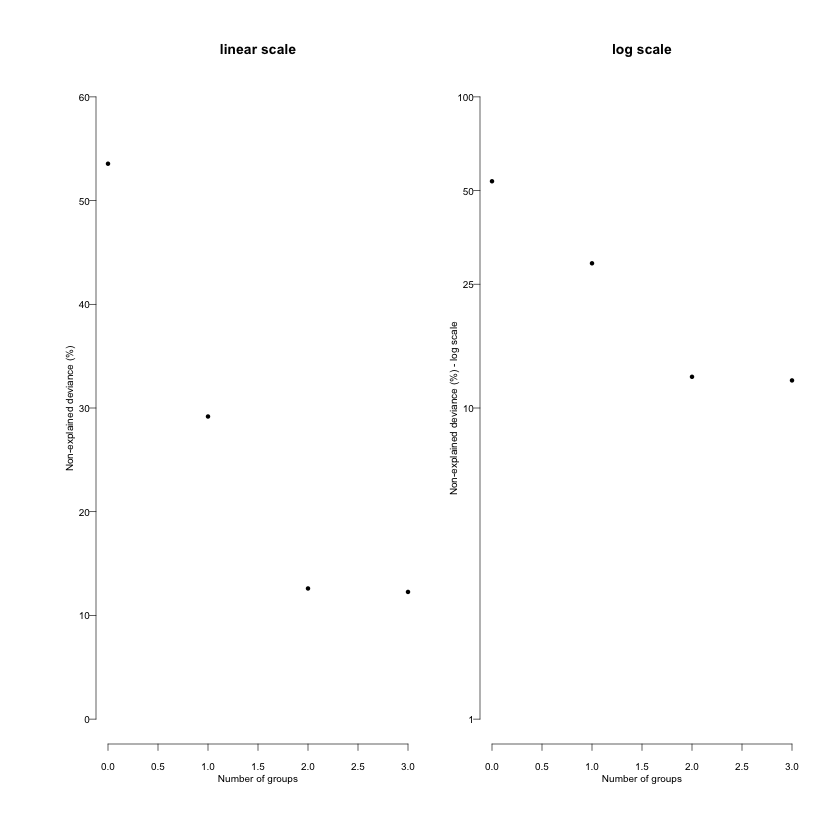

In [10]:
# Look at max deviance explained for different k
df_explained_dev <- data.frame(
    "N_groups" = 0:length(potential_splits$best_dev_explained),
    "Non_explained_deviance" = (1 - c(potential_splits$first_dev, potential_splits$best_dev_explained)),
    "Non_explained_deviance_log" = log(1 - c(potential_splits$first_dev, potential_splits$best_dev_explained))
)
df_explained_dev$Non_explained_deviance_log <- df_explained_dev$Non_explained_deviance_log - min(df_explained_dev$Non_explained_deviance_log)

par(mfrow = c(1, 2), oma = c(2, 2, 1, 1), mar = c(2, 2, 2, 0.5), mgp = c(0.75, 0.25, 0), cex.axis = 0.5, cex.lab = 0.5, cex.main = 0.7, cex.sub = 0.5)
plot(df_explained_dev$N_groups,
    df_explained_dev$Non_explained_deviance,
    bty = "n", ylim = c(0, ceiling(10 * max(df_explained_dev$Non_explained_deviance)) / 10),
    xaxt = "n", yaxt = "n", pch = 16, main = "linear scale", cex = 0.5,
    ylab = "Non-explained deviance (%)", xlab = "Number of groups"
)
axis(1, lwd = 0.5, tck = -0.02)
axis(2,
    las = 2, at = seq(0, ceiling(10 * max(df_explained_dev$Non_explained_deviance)) / 10, 0.1),
    labels = seq(0, ceiling(10 * max(df_explained_dev$Non_explained_deviance)) / 10, 0.1) * 100, lwd = 0.5, tck = -0.02
)

plot(df_explained_dev$N_groups,
    (df_explained_dev$Non_explained_deviance),
    log = "y",
    ylim = c(0.01, 1),
    bty = "n",
    xaxt = "n", yaxt = "n", pch = 16, main = "log scale", cex = 0.5,
    ylab = "Non-explained deviance (%) - log scale", xlab = "Number of groups"
)
axis(1, lwd = 0.5, tck = -0.02)
axis(2,
    las = 2, at = c(0.01, 0.1, 0.25, 0.5, 1),
    labels = c(0.01, 0.1, 0.25, 0.5, 1) * 100, lwd = 0.5, tck = -0.02
)


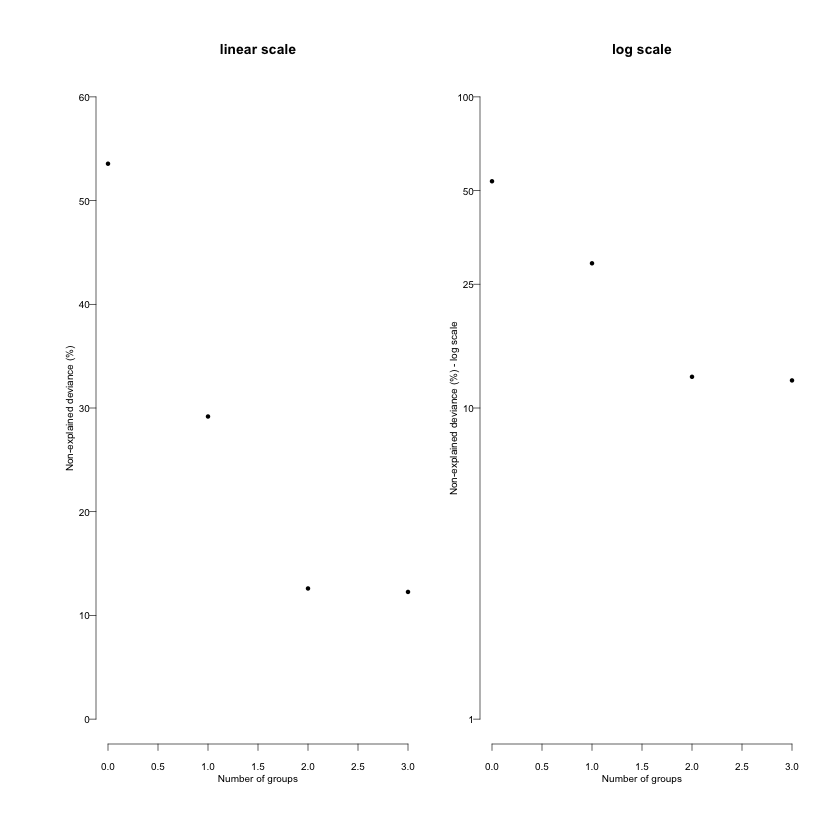

In [13]:
# Look at max deviance explained for different k
df_explained_dev <- data.frame(
    "N_groups" = 0:length(potential_splits$best_dev_explained),
    "Non_explained_deviance" = (1 - c(potential_splits$first_dev, potential_splits$best_dev_explained)),
    "Non_explained_deviance_log" = log(1 - c(potential_splits$first_dev, potential_splits$best_dev_explained))
)
df_explained_dev$Non_explained_deviance_log <- df_explained_dev$Non_explained_deviance_log - min(df_explained_dev$Non_explained_deviance_log)

par(mfrow = c(1, 2), oma = c(2, 2, 1, 1), mar = c(2, 2, 2, 0.5), mgp = c(0.75, 0.25, 0), cex.axis = 0.5, cex.lab = 0.5, cex.main = 0.7, cex.sub = 0.5)
plot(df_explained_dev$N_groups,
    df_explained_dev$Non_explained_deviance,
    bty = "n", ylim = c(0, ceiling(10 * max(df_explained_dev$Non_explained_deviance)) / 10),
    xaxt = "n", yaxt = "n", pch = 16, main = "linear scale", cex = 0.5,
    ylab = "Non-explained deviance (%)", xlab = "Number of groups"
)
axis(1, lwd = 0.5, tck = -0.02)
axis(2,
    las = 2, at = seq(0, ceiling(10 * max(df_explained_dev$Non_explained_deviance)) / 10, 0.1),
    labels = seq(0, ceiling(10 * max(df_explained_dev$Non_explained_deviance)) / 10, 0.1) * 100, lwd = 0.5, tck = -0.02
)

plot(df_explained_dev$N_groups,
    (df_explained_dev$Non_explained_deviance),
    log = "y",
    ylim = c(0.01, 1),
    bty = "n",
    xaxt = "n", yaxt = "n", pch = 16, main = "log scale", cex = 0.5,
    ylab = "Non-explained deviance (%) - log scale", xlab = "Number of groups"
)
axis(1, lwd = 0.5, tck = -0.02)
axis(2,
    las = 2, at = c(0.01, 0.1, 0.25, 0.5, 1),
    labels = c(0.01, 0.1, 0.25, 0.5, 1) * 100, lwd = 0.5, tck = -0.02
)


In [14]:
split <- merge.groups(
    timed_tree = tree_antigen_sim, metadata = dataset_with_nodes,
    initial_splits = potential_splits$potential_splits,
    group_count_threshold = min_group_size, group_freq_threshold = 0.01
)

In [15]:
## Label sequences with new groups
dataset_with_nodes$groups <- as.factor(split$groups)
## Reorder labels by time of emergence
name_groups <- levels(dataset_with_nodes$groups)
time_groups_world <- NULL
for (i in 1:length(name_groups)) {
    time_groups_world <- c(time_groups_world, min(dataset_with_nodes$time[which(dataset_with_nodes$groups == name_groups[i] &
        dataset_with_nodes$is.node == "no")]))
}
levels(dataset_with_nodes$groups) <- match(name_groups, order(time_groups_world, decreasing = T))
dataset_with_nodes$groups <- as.numeric(as.character(dataset_with_nodes$groups))
dataset_with_nodes$groups <- as.factor(dataset_with_nodes$groups)
## Update names in split list
split$tip_and_nodes_groups <- match(split$tip_and_nodes_groups, order(time_groups_world, decreasing = T))
names(split$tip_and_nodes_groups) <- 1:length(split$tip_and_nodes_groups)
split$groups <- as.factor(split$groups)
levels(split$groups) <- match(name_groups, order(time_groups_world, decreasing = T))
split$groups <- as.numeric(as.character(split$groups))
## Choose color palette
n_groups <- length(name_groups)
colors_groups <- (met.brewer(name = "Cross", n = n_groups, type = "continuous"))
## Color each group
dataset_with_nodes$group_color <- dataset_with_nodes$groups
levels(dataset_with_nodes$group_color) <- colors_groups
dataset_with_nodes$group_color <- as.character(dataset_with_nodes$group_color)

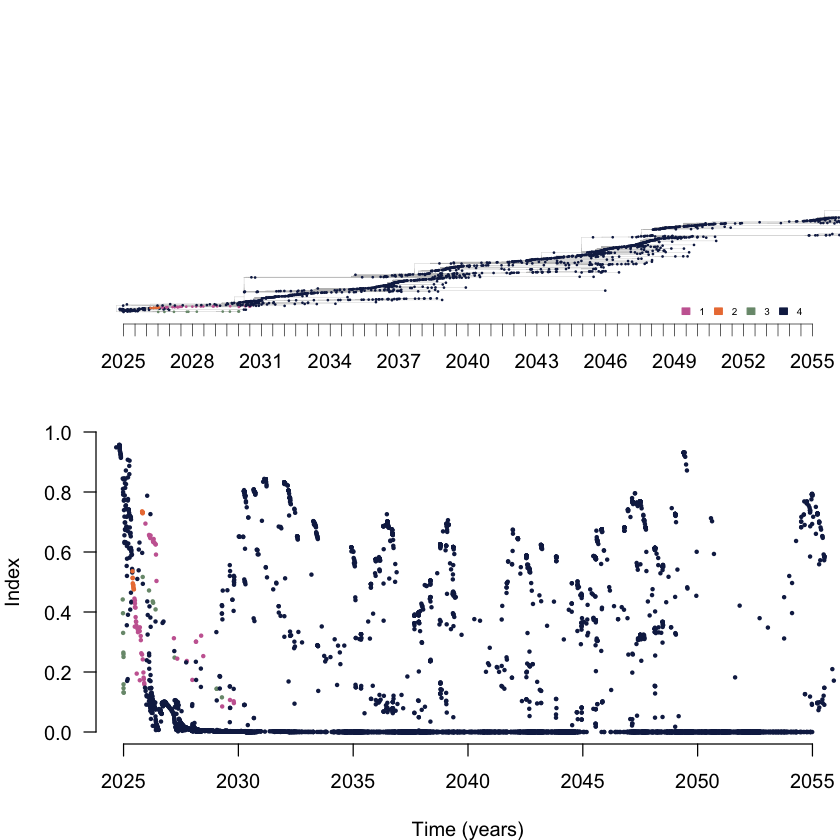

In [16]:
par(mfrow = c(2, 1), oma = c(0, 0, 0, 0), mar = c(4, 4, 0, 0))

## Tree
plot(tree_antigen_sim,
    show.tip.label = FALSE,
    edge.color = "grey", edge.width = 0.25,
    x.lim = c(min_year, max_year) - root_height
)
tiplabels(pch = 16, col = dataset_with_nodes$group_color, cex = 0.3)
axisPhylo_NL(
    side = 1, root.time = root_height, backward = F,
    at_axis = seq(min_year, max_year, 0.5) - root_height,
    lab_axis = seq(min_year, max_year, 0.5), lwd = 0.5
)
# Color key
legend("bottomright",
    legend = name_groups,
    fill = colors_groups, border = colors_groups,
    cex = 0.5, bty = "n", ncol = 5
)

## Index colored by group
plot(dataset_with_nodes$time,
    dataset_with_nodes$index,
    col = adjustcolor(dataset_with_nodes$group_color, alpha.f = 1),
    bty = "n", xlim = c(min_year, max_year), cex = 0.5,
    pch = 16, bty = "n", # ylim = c(0, 1),
    main = paste0(""), # log = 'y',
    ylab = "Index", xlab = "Time (years)", yaxt = "n"
)
axis(2, las = 2)

In [17]:
length(dataset_with_nodes$groups)

[1] 10949

In [18]:
table(dataset_with_nodes$is.node)


  no  yes 
5475 5474 

In [ ]:
# Subset to tips only
dataset_tips <- dataset_with_nodes[which(dataset_with_nodes$is.node == "no"), ]

In [ ]:
head(dataset_tips)

In [ ]:
# Dump results to file
results_path <- "data/flu-simulated-150k-samples-final/phylowave_clustering_results.tsv"
write.table(dataset_tips[, c("name_seq", "index", "groups")],
    file = results_path, sep = "\t", row.names = F, col.names = T, quote = F
)